This file converts the 2019 studies mat data into pkl files for Python analysis

In [ ]:
import h5py
import matplotlib.pyplot as plt
import numpy as np
import pickle
import os

In [8]:
def mat_to_pkl(input_filename, output_filename, batch_num=None):
    f = h5py.File(input_filename, 'r')

    def h5read(ref):
        return np.array(f[ref])

    def h5read_flat(ref):
        return h5read(ref).squeeze()

    batch = f['batch']
    num_cells = batch["summary"].shape[0]
    bat_dict = {}

    for i in range(num_cells):
        cl = h5read(batch["cycle_life"][i, 0]).item()

        policy = (
            h5read(batch["policy_readable"][i, 0])
            .tobytes()[::2]
            .decode()
            .replace("\x00", "")
        )

        summary_ref = f[batch["summary"][i, 0]]

        summary = {
            "IR": np.hstack(summary_ref["IR"][0, :].tolist()),
            "QC": np.hstack(summary_ref["QCharge"][0, :].tolist()),
            "QD": np.hstack(summary_ref["QDischarge"][0, :].tolist()),
            "Tavg": np.hstack(summary_ref["Tavg"][0, :].tolist()),
            "Tmin": np.hstack(summary_ref["Tmin"][0, :].tolist()),
            "Tmax": np.hstack(summary_ref["Tmax"][0, :].tolist()),
            "chargetime": np.hstack(summary_ref["chargetime"][0, :].tolist()),
            "cycle": np.hstack(summary_ref["cycle"][0, :].tolist()),
        }

        cycles_ref = f[batch["cycles"][i, 0]]
        cycle_dict = {}

        for j in range(cycles_ref["I"].shape[0]):
            cd = {
                "I": h5read_flat(cycles_ref["I"][j, 0]),
                "Qc": h5read_flat(cycles_ref["Qc"][j, 0]),
                "Qd": h5read_flat(cycles_ref["Qd"][j, 0]),
                "Qdlin": h5read_flat(cycles_ref["Qdlin"][j, 0]),
                "T": h5read_flat(cycles_ref["T"][j, 0]),
                "Tdlin": h5read_flat(cycles_ref["Tdlin"][j, 0]),
                "V": h5read_flat(cycles_ref["V"][j, 0]),
                "dQdV": h5read_flat(cycles_ref["discharge_dQdV"][j, 0]),
                "t": h5read_flat(cycles_ref["t"][j, 0]),
            }
            cycle_dict[str(j)] = cd

        bat_dict[f"b{batch_num}c{i}"] = {
            "cycle_life": cl,
            "charge_policy": policy,
            "summary": summary,
            "cycles": cycle_dict,
        }

    print(f"Loaded {len(bat_dict)} cells")

    # Ensure output directory exists
    os.makedirs(os.path.dirname(output_filename), exist_ok=True)

    # Ensure .pkl extension
    if not output_filename.endswith(".pkl"):
        output_filename += ".pkl"

    with open(output_filename, "wb") as f_out:
        pickle.dump(bat_dict, f_out, protocol=pickle.HIGHEST_PROTOCOL)

    print(f"Saved to {output_filename}")

    return bat_dict

In [9]:
data1 = mat_to_pkl('../data/2017-05-12_batchdata_updated_struct_errorcorrect.mat', "../data/batch1.pkl", batch_num=1)
data2 = mat_to_pkl('../data/2017-06-30_batchdata_updated_struct_errorcorrect.mat', "../data/batch2.pkl", batch_num=2)
data3 = mat_to_pkl('../data/2018-04-12_batchdata_updated_struct_errorcorrect.mat', "../data/batch3.pkl", batch_num=3)

Loaded 46 cells
Saved to ../data/batch1.pkl
Loaded 48 cells
Saved to ../data/batch2.pkl
Loaded 46 cells
Saved to ../data/batch3.pkl


In [10]:
print("data1 keys:", list(data1.keys()))
print("data2 keys:", list(data2.keys()))
print("data3 keys:", list(data3.keys()))

data1 keys: ['b1c0', 'b1c1', 'b1c2', 'b1c3', 'b1c4', 'b1c5', 'b1c6', 'b1c7', 'b1c8', 'b1c9', 'b1c10', 'b1c11', 'b1c12', 'b1c13', 'b1c14', 'b1c15', 'b1c16', 'b1c17', 'b1c18', 'b1c19', 'b1c20', 'b1c21', 'b1c22', 'b1c23', 'b1c24', 'b1c25', 'b1c26', 'b1c27', 'b1c28', 'b1c29', 'b1c30', 'b1c31', 'b1c32', 'b1c33', 'b1c34', 'b1c35', 'b1c36', 'b1c37', 'b1c38', 'b1c39', 'b1c40', 'b1c41', 'b1c42', 'b1c43', 'b1c44', 'b1c45']
data2 keys: ['b2c0', 'b2c1', 'b2c2', 'b2c3', 'b2c4', 'b2c5', 'b2c6', 'b2c7', 'b2c8', 'b2c9', 'b2c10', 'b2c11', 'b2c12', 'b2c13', 'b2c14', 'b2c15', 'b2c16', 'b2c17', 'b2c18', 'b2c19', 'b2c20', 'b2c21', 'b2c22', 'b2c23', 'b2c24', 'b2c25', 'b2c26', 'b2c27', 'b2c28', 'b2c29', 'b2c30', 'b2c31', 'b2c32', 'b2c33', 'b2c34', 'b2c35', 'b2c36', 'b2c37', 'b2c38', 'b2c39', 'b2c40', 'b2c41', 'b2c42', 'b2c43', 'b2c44', 'b2c45', 'b2c46', 'b2c47']
data3 keys: ['b3c0', 'b3c1', 'b3c2', 'b3c3', 'b3c4', 'b3c5', 'b3c6', 'b3c7', 'b3c8', 'b3c9', 'b3c10', 'b3c11', 'b3c12', 'b3c13', 'b3c14', 'b3c15', '

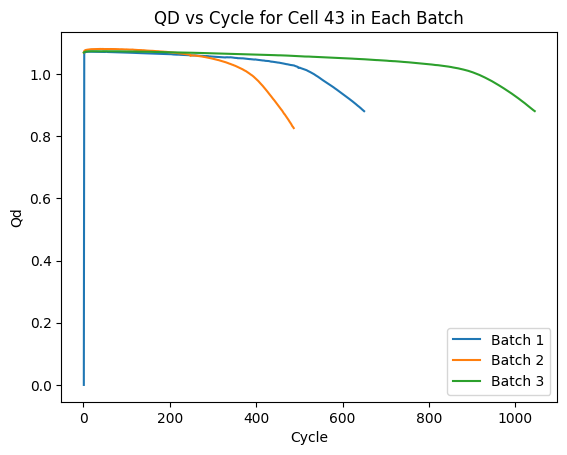

In [12]:
plt.plot(data1['b1c43']['summary']['cycle'], data1['b1c43']['summary']['QD'])
plt.plot(data2['b2c43']['summary']['cycle'], data2['b2c43']['summary']['QD'])
plt.plot(data3['b3c43']['summary']['cycle'], data3['b3c43']['summary']['QD'])
plt.xlabel('Cycle')
plt.ylabel('Qd')
plt.title('QD vs Cycle for Cell 43 in Each Batch')
plt.legend(['Batch 1', 'Batch 2', 'Batch 3'])
plt.show()